# Fig: Distribution of last Pmax in mismatch agentHigher scenario: pmax_th=0.95

Reference: 
- `20260531_fig_infotaxis_MAP_cmp_pmax0.95.ipynb`

In [1]:
from pathlib import Path

import pandas as pd

import seaborn as sns

In [2]:
from plot_utils import bar_violinplot_last_pmax
from simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

Samples: left:  989    right:  996
Mean:    left: 0.987  right: 0.980
Median:  left: 0.988  right: 0.987

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  989    right:  999
Mean:    left: 0.987  right: 0.982
Median:  left: 0.988  right: 0.985

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  989    right: 1000
Mean:    left: 0.987  right: 0.972
Median:  left: 0.988  right: 0.972

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  989    right: 1000
Mean:    left: 0.987  right: 0.968
Median:  left: 0.988  right: 0.969

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


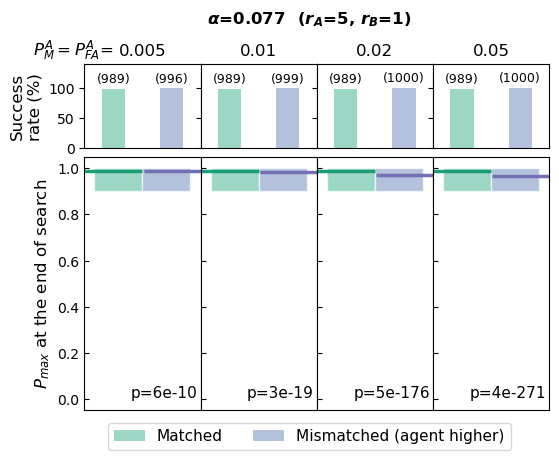

Samples: left:  977    right:  997
Mean:    left: 0.980  right: 0.978
Median:  left: 0.981  right: 0.981

MWU test
 - different: 0.00025
 - less:      0.99988
 - greater:   0.00012
--------------------------------------------
Samples: left:  977    right: 1000
Mean:    left: 0.980  right: 0.970
Median:  left: 0.981  right: 0.972

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  977    right: 1000
Mean:    left: 0.980  right: 0.966
Median:  left: 0.981  right: 0.967

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  977    right: 1000
Mean:    left: 0.980  right: 0.963
Median:  left: 0.981  right: 0.961

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


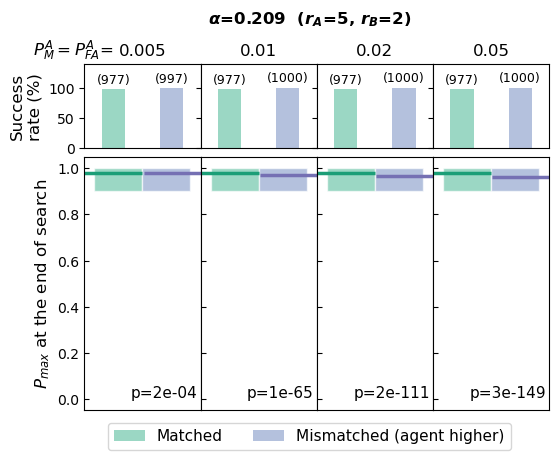

Samples: left:  986    right: 1000
Mean:    left: 0.983  right: 0.985
Median:  left: 0.985  right: 0.989

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  986    right: 1000
Mean:    left: 0.983  right: 0.984
Median:  left: 0.985  right: 0.989

MWU test
 - different: 0.00575
 - less:      0.00288
 - greater:   0.99713
--------------------------------------------
Samples: left:  986    right: 1000
Mean:    left: 0.983  right: 0.973
Median:  left: 0.985  right: 0.975

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  986    right: 1000
Mean:    left: 0.983  right: 0.968
Median:  left: 0.985  right: 0.969

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


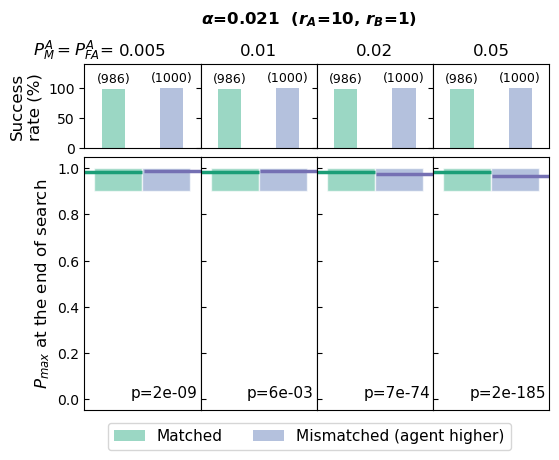

Samples: left:  980    right:  998
Mean:    left: 0.979  right: 0.978
Median:  left: 0.979  right: 0.980

MWU test
 - different: 0.00339
 - less:      0.99830
 - greater:   0.00170
--------------------------------------------
Samples: left:  980    right:  998
Mean:    left: 0.979  right: 0.970
Median:  left: 0.979  right: 0.971

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  980    right: 1000
Mean:    left: 0.979  right: 0.965
Median:  left: 0.979  right: 0.965

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  980    right: 1000
Mean:    left: 0.979  right: 0.959
Median:  left: 0.979  right: 0.957

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


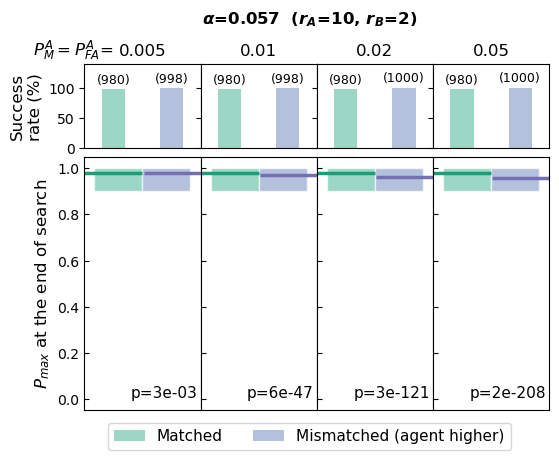

In [4]:
cr_all = [5, 10]
br_all = [1, 2]
pm_agent_all = [0.005, 0.01, 0.02, 0.05]
pm_truth_all = [0.001] * len(pm_agent_all)


for cr in cr_all:
    for br in br_all:

        path_left = path_data / "20260530_infotaxis_match_summary_compiled_pmax095_pmaxDiff1e-5"
        path_right = path_data / "20260530_infotaxis_mismatch_agentHigher_summary_compiled_pmax095_pmaxDiff1e-5"
        pmax_th = 0.95
        pmax_diff_th = 1e-5

        df_x_all = []
        df_y_all = []
        for pm_agent, pm_truth in zip(pm_agent_all, pm_truth_all):
            # Load summary and ph details
            df_x = pd.read_csv(
                path_left / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm_truth
                ), index_col=0
            )
            df_y = pd.read_csv(
                path_right / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="mismatch",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm_agent, pm_truth=pm_truth
                ), index_col=0
            )
            df_x_all.append(df_x)
            df_y_all.append(df_y)

        
        fig = bar_violinplot_last_pmax(
            cr=cr, br=br, pm_all=pm_agent_all,
            df_x_all=df_x_all, df_y_all=df_y_all,
            x_str="Matched", y_str="Mismatched (agent higher)",
            comparison_type="agent_higher",
            stats_type="two-sided",
            colors=sns.color_palette("Set2"),
            colors_dark=sns.color_palette("Dark2"),
            bar_step=0.1,
            color_idx_left=0, color_idx_right=2,
            alpha=0.65
        )

        fig.savefig(
            path_fig / f"fig_last_pmax_mismatch_agentHigher_cr{cr}_br{br}_pmaxTh0.95_pmaxDiff1e-5.png",
            dpi=300, bbox_inches="tight"
        )